# Customer Churn — Model Training, Evaluation & Inference

This notebook covers:
1. Loading and exploring the raw dataset
2. Documenting data quality issues found (and how they were handled)
3. Training and comparing candidate models
4. Justifying the evaluation metric
5. Checking probability calibration
6. Final model training + held-out evaluation
7. A clean, callable `predict_churn_risk(customer_id)` inference function
8. What-if scoring and aggregate/segment queries (the building blocks Stage 3's agent will call as tools)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
sns.set_style('whitegrid')
RANDOM_STATE = 42


## 1. Load the data

In [ ]:
raw = pd.read_csv('backend/dataset/customer_churn.csv')
print('shape:', raw.shape)
raw.head()


shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
raw.dtypes


customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

**First red flag:** `TotalCharges` is typed as an object/string column, not numeric 

## 2. Exploratory Data Analysis & Data Quality Issues

### 2.1 Target distribution

Churn rate: 26.537%


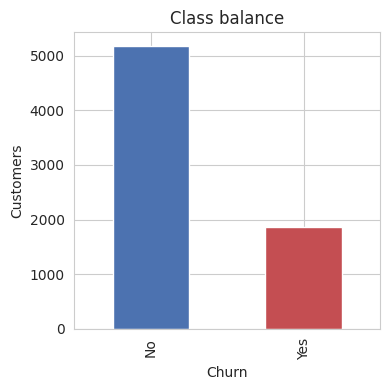

In [ ]:
churn_rate = (raw['Churn'] == 'Yes').mean()
print(f"Churn rate: {churn_rate}")

fig, ax = plt.subplots(figsize=(4,4))
raw['Churn'].value_counts().plot(kind='bar', ax=ax, color=['#4C72B0','#C44E52'])
ax.set_title('Class balance')
ax.set_ylabel('Customers')
plt.tight_layout()
plt.show()


**Finding:** 26.5% churn, this is a mild-to-moderate imbalance. This means that oversampling techniques like SMOTE may not be too impactful if used

### 2.2 Missing values (naive check)

In [ ]:
raw.isna().sum()[raw.isna().sum() > 0]


Series([], dtype: int64)

`.isna()` reports **zero** missing values. But TotalCharges sometimes show empty cells when I saw, maybe they have empty strings

### 2.3 The real TotalCharges problem

In [ ]:
total_charges_numeric = pd.to_numeric(raw['TotalCharges'], errors='coerce')
bad_rows = raw[total_charges_numeric.isna()]
print(f"Rows where TotalCharges isn't a real number: {len(bad_rows)}")
bad_rows[['customerID','tenure','MonthlyCharges','TotalCharges','Contract','Churn']]


Rows where TotalCharges isn't a real number: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


**Finding:** 11 rows have `TotalCharges = " "` (a blank space). Every one of these rows has:
- `tenure == 0`
- `Churn == 'No'`
- mostly one/two-year contracts

These are brand-new signups who haven't been billed yet, it's absent because no bill has been generated. 

We will not drop these rows because it will cause data loss of real customers. And also cant fill by mean because that would be misleading for new customers. A goog decision is **impute `0.0`**

### 2.4 Redundant categorical encodings

In [ ]:
noint_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for c in noint_cols:
    exact_match = ((raw[c] == 'No internet service') == (raw['InternetService'] == 'No')).all()
    print(f"{c:20s} 'No internet service' exactly matches InternetService=='No': {exact_match}")

phone_match = ((raw['MultipleLines'] == 'No phone service') == (raw['PhoneService'] == 'No')).all()
print(f"{'MultipleLines':20s} 'No phone service' exactly matches PhoneService=='No':   {phone_match}")


OnlineSecurity       'No internet service' exactly matches InternetService=='No': True
OnlineBackup         'No internet service' exactly matches InternetService=='No': True
DeviceProtection     'No internet service' exactly matches InternetService=='No': True
TechSupport          'No internet service' exactly matches InternetService=='No': True
StreamingTV          'No internet service' exactly matches InternetService=='No': True
StreamingMovies      'No internet service' exactly matches InternetService=='No': True
MultipleLines        'No phone service' exactly matches PhoneService=='No':   True


**Finding:** all six internet add-on columns carry a `"No internet service"` category that is **100% redundant** with `InternetService == 'No'` (1,526 rows). it's the same fact restated seven times. Same for `MultipleLines`'s `"No phone service"` vs `PhoneService`. 

If not fixed one-hot encoding would make 7 dummy columns encoding a single binary fact. 

**Decision: collapse `"No internet service"` and `"No phone service"` down to `"No"`** 

### 2.5 TotalCharges is a derived feature

In [ ]:
d = raw.copy()
d['TotalCharges'] = total_charges_numeric
d = d.dropna(subset=['TotalCharges'])

corr = np.corrcoef(d['tenure'], d['TotalCharges'])[0,1]
residual = (d['TotalCharges'] - d['tenure'] * d['MonthlyCharges']).abs()
print(f"corr(tenure, TotalCharges)          = {corr:.3f}")
print(f"median |TotalCharges - tenure*MonthlyCharges| = {residual.median():.2f}")
print(f"95th pct of that residual                     = {residual.quantile(0.95):.2f}")


corr(tenure, TotalCharges)          = 0.826
median |TotalCharges - tenure*MonthlyCharges| = 28.65
95th pct of that residual                     = 147.21


**Finding:** `TotalCharges` correlates 0.83 with `tenure` and is closely approximated by `tenure × MonthlyCharges`. This maybe a redundant column for linear classifiers but not for trees

### 2.6 Churn rate by key segments

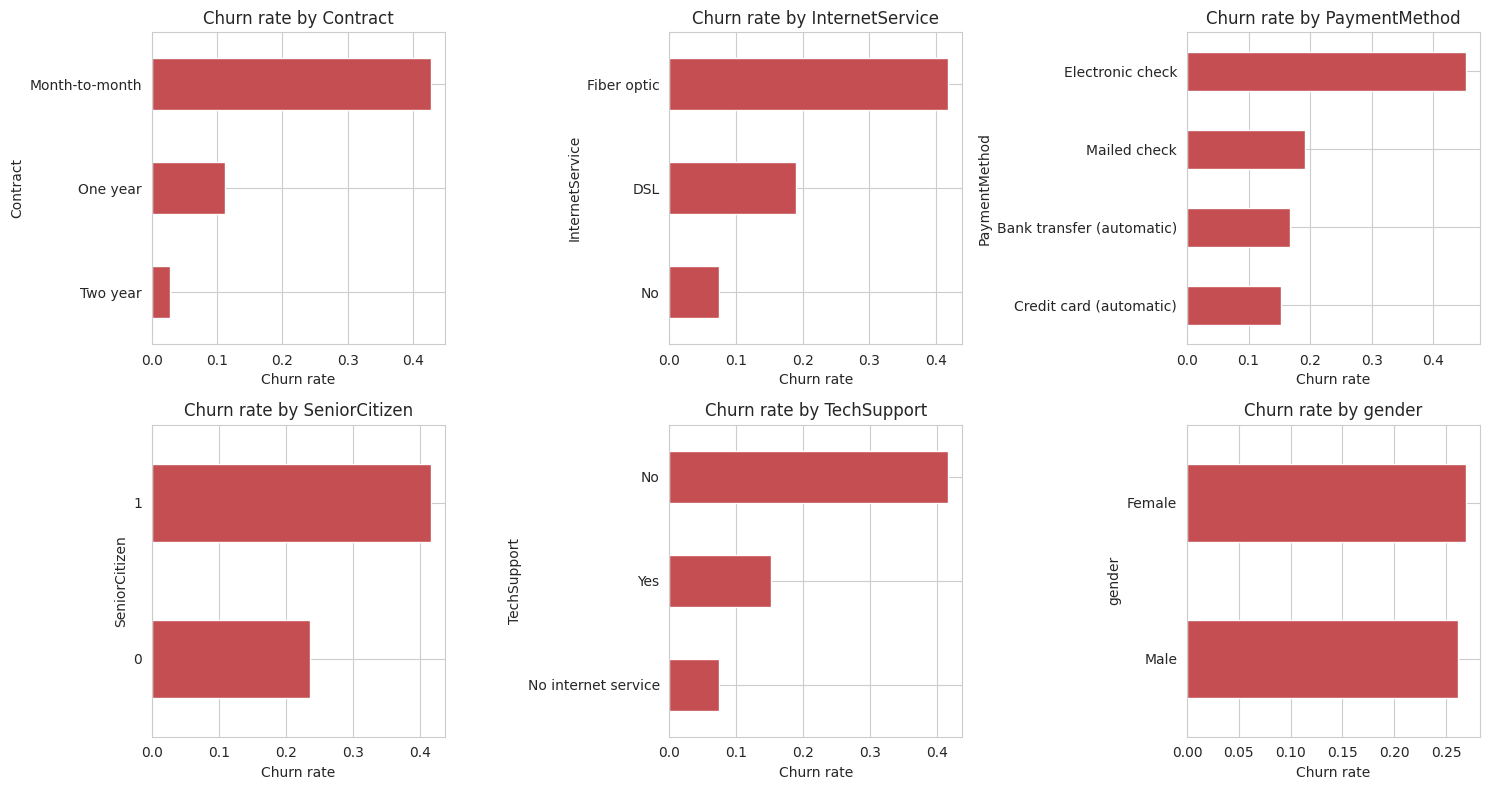

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
segment_cols = ['Contract','InternetService','PaymentMethod','SeniorCitizen','TechSupport','gender']
for ax, col in zip(axes.flat, segment_cols):
    rates = raw.groupby(col)['Churn'].apply(lambda s: (s=='Yes').mean()).sort_values()
    rates.plot(kind='barh', ax=ax, color='#C44E52')
    ax.set_title(f'Churn rate by {col}')
    ax.set_xlabel('Churn rate')
plt.tight_layout()
plt.show()


**Findings:**
- **Contract** is the strongest single driver: month-to-month churns at ~43% vs. ~3% for two-year contracts.
- **Fiber optic** internet churns much more (~42%) than DSL (~19%) or no internet (~7%) — possibly price or service-quality related.
- **Electronic check** payers churn far more (~45%) than automatic payment methods (~15-17%) — friction-to-leave matters.
- **Senior citizens** churn more (~42% vs ~24%).

#### Noise
- **gender is essentially noise** — 26.9% vs 26.2%, no real difference. Kept in the model for completeness/transparency